<a href="https://colab.research.google.com/github/notmakgg-ux/GPT-build-by-me/blob/main/TrainingMyGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Building my own GPT from scratch.
 * Today I am learning and building my own GPT from scratch. This will help me
learn the base needed for LLM.
* The flow of the GPT is as follows :-

1.   Tokenization
2.   Embedding
3. Positional encoding
4. Attention
5. Transformer Block
6. GPT model
7. Data
8. Training
9.  Generation
10. Evaluation
11. Attention Visualization
12. Ablation Experiments



## 1. Tokenization

In [1]:
from dataclasses import dataclass
!pip install -q tiktoken
import tiktoken

In [2]:
@dataclass
class TokenizerConfig:
    name: str = "gpt2"
    vocab_size: int = 50257

In [3]:
class SimpleTokenizer:
  def __init__(self, config=None):
    self.config=config or TokenizerConfig()
    self.enc= tiktoken.get_encoding(self.config.name)
    self.eos_token="<|endoftext|>"
    self.eos_token_id=self.enc.encode(
        self.eos_token,  allowed_special={self.eos_token}
    )[0]
  def encode(self, text):
    return self.enc.encode(text , allowed_special={self.eos_token})

  def decode(self,ids):
    return self.enc.decode(ids)

  @property
  def vocab_size(self):
    return self.enc.n_vocab

In [4]:
tokenizer = SimpleTokenizer()
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"EOS token: {tokenizer.eos_token}")
print(f"EOS token ID: {tokenizer.eos_token_id}")
print()

text = "The quick brown fox jumps over the lazy dog."
print(f"Original text: {text}")
encoded = tokenizer.encode(text)
print(f"Encoded text: {encoded}")
decoded = tokenizer.decode(encoded)
print(f"Decoded text: {decoded}")
print(f"Roundtrip: {text == decoded}")


Vocab size: 50257
EOS token: <|endoftext|>
EOS token ID: 50256

Original text: The quick brown fox jumps over the lazy dog.
Encoded text: [464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290, 13]
Decoded text: The quick brown fox jumps over the lazy dog.
Roundtrip: True


In [5]:
rare = tokenizer.encode("antidisestablishmentarianism")
pieces = [tokenizer.decode([t]) for t in rare]
print(f"Pieces: {pieces}")
print(f"Decoded: '{tokenizer.decode(rare)}'")
print()

text = tokenizer.encode("Hello world!")
print(f"Decoded: {tokenizer.decode(text)}")
print()
emoji = tokenizer.encode("Hello \U0001f60a world")
print(f"Emoji test: {tokenizer.decode(emoji)}")

Pieces: ['ant', 'idis', 'establishment', 'arian', 'ism']
Decoded: 'antidisestablishmentarianism'

Decoded: Hello world!

Emoji test: Hello 😊 world


## 2. Embedding

In [6]:
import torch
import torch.nn as nn
import math

In [7]:
class Embedding(nn.Module):
  def __init__(self, vocab_size, d_model):
    super().__init__()
    self.embed=nn.Embedding(vocab_size,d_model)

  def forward(self,x):
    return self.embed(x)


In [8]:
vocab_size = 1000
d_model = 768

embedding = Embedding(vocab_size, d_model)
print(f"Embedding table shape: [{vocab_size}, {d_model}]")
print(f"Total parameters: {sum(p.numel() for p in embedding.parameters()):,}")
print()

token_ids = torch.tensor([[123, 45, 678, 464, 890]])
print(f"Input token IDs: {token_ids}")
print(f"Input shape: {token_ids.shape}")
print()

output = embedding(token_ids)
print(f"Output shape: {output.shape}")
print(f"Each token is now a {d_model}-dimensional vector")
print(f"First token vector preview: {output[0, 0, :5].tolist()} ...")

Embedding table shape: [1000, 768]
Total parameters: 768,000

Input token IDs: tensor([[123,  45, 678, 464, 890]])
Input shape: torch.Size([1, 5])

Output shape: torch.Size([1, 5, 768])
Each token is now a 768-dimensional vector
First token vector preview: [-1.8708726167678833, 0.18449874222278595, -0.03743203729391098, 0.8524971604347229, -0.2630249559879303] ...


## 3. Postional Encoding Using RoPE

In [9]:
import torch
import torch.nn as nn
import math

In [10]:
class RotaryPositionalEmbedding(nn.Module):
  def __init__(self, d_model, max_seq_len=2048, theta=10000.0):
    super().__init__()
    assert d_model%2==0, "d_model must be even"


    dim_indices=torch.arange(0, d_model, 2).float()
    inv_freq=1.0 / (theta ** (dim_indices / d_model))

    positions = torch.arange(max_seq_len).float()
    freqs=torch.outer(positions, inv_freq)
    emb = freqs.repeat_interleave(2, dim=-1)

    self.register_buffer("cos_cached", emb.cos())
    self.register_buffer("sin_cached", emb.sin())


  @staticmethod
  def rotate_half(x):

    x_even = x[..., 0::2]
    x_odd  = x[..., 1::2]
    return torch.stack([-x_odd, x_even], dim=-1).flatten(-2)

  def forward(self, x, seq_len):

    cos = self.cos_cached[:seq_len].to(x.dtype).unsqueeze(0).unsqueeze(0)
    sin = self.sin_cached[:seq_len].to(x.dtype).unsqueeze(0).unsqueeze(0)
    return (x * cos) + (self.rotate_half(x) * sin)





In [11]:
rope = RotaryPositionalEmbedding(d_model=4, max_seq_len=16)

q = torch.tensor([[[[0.8, 0.3, -0.5, 0.2]]]])  # [1, 1, 1, 4]
print(f"Original vector: {q[0, 0, 0].tolist()}")
print()

for pos in [0, 1, 2, 5]:
    rotated = rope(q, seq_len=pos + 1)
    last = rotated[0, 0, -1].tolist()
    vals = [f"{v:.3f}" for v in last]
    print(f"Position {pos}: [{', '.join(vals)}]")

Original vector: [0.800000011920929, 0.30000001192092896, -0.5, 0.20000000298023224]

Position 0: [0.800, 0.300, -0.500, 0.200]
Position 1: [0.180, 0.835, -0.502, 0.195]
Position 2: [-0.606, 0.603, -0.504, 0.190]
Position 5: [0.515, -0.682, -0.509, 0.175]


In [12]:

rope = RotaryPositionalEmbedding(d_model=64, max_seq_len=256)

seq_len = 12
# SAME vector at every position, so only the rotation differs
q0 = torch.randn(1, 1, 1, 64).expand(1, 1, seq_len, 64)
k0 = torch.randn(1, 1, 1, 64).expand(1, 1, seq_len, 64)

q_rot = rope(q0, seq_len)
k_rot = rope(k0, seq_len)

def score(i, j):
    return (q_rot[0, 0, i] @ k_rot[0, 0, j]).item()

print(f"Distance 2, positions (2,4): {score(2, 4):.4f}")
print(f"Distance 2, positions (5,7): {score(5, 7):.4f}")
print(f"Distance 2, positions (0,2): {score(0, 2):.4f}")
print(f"Distance 8, positions (0,8): {score(0, 8):.4f}")
print()
print("Same distance -> same score. RoPE encodes RELATIVE position.")
assert math.isclose(score(2, 4), score(5, 7), rel_tol=1e-4, abs_tol=1e-3)
assert math.isclose(score(2, 4), score(0, 2), rel_tol=1e-4, abs_tol=1e-3)

Distance 2, positions (2,4): -9.6804
Distance 2, positions (5,7): -9.6804
Distance 2, positions (0,2): -9.6804
Distance 8, positions (0,8): -6.1494

Same distance -> same score. RoPE encodes RELATIVE position.


## 4. Attention

In [13]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [14]:
def create_causal_mask(seq_len, device):
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask.view(1, 1, seq_len, seq_len)

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1,
                 use_rope=True, max_seq_len=2048):
        super().__init__()

        assert d_model % num_heads == 0, \
            "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.use_rope = use_rope

        self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)


        self.rope = (
            RotaryPositionalEmbedding(self.head_dim, max_seq_len)
            if use_rope else None
        )

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)


        self.store_attn = False
        self.last_attn = None

    def forward(self, x, mask=None):
        batch_size, seq_len, d_model = x.shape

        qkv = self.qkv_proj(x)
        qkv = qkv.reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        if self.use_rope:
            q = self.rope(q, seq_len)
            k = self.rope(k, seq_len)

        attn_weights = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            attn_weights = attn_weights.masked_fill(mask == 0, float("-inf"))

        attn_weights = F.softmax(attn_weights, dim=-1)

        if self.store_attn:
            self.last_attn = attn_weights.detach().cpu()

        attn_weights = self.attn_dropout(attn_weights)
        attn_output = attn_weights @ v

        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(batch_size, seq_len, self.d_model)

        output = self.out_proj(attn_output)
        output = self.resid_dropout(output)
        return output

In [16]:
attn = MultiHeadAttention(d_model=768, num_heads=12)

batch_size = 8
seq_len = 64
x = torch.randn(batch_size, seq_len, 768)
mask = create_causal_mask(seq_len, x.device)

output = attn(x, mask)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Input and output shapes match: {x.shape == output.shape}")
print()

params = sum(p.numel() for p in attn.parameters())
print(f"Attention parameters: {params:,}")


Input shape:  torch.Size([8, 64, 768])
Output shape: torch.Size([8, 64, 768])
Input and output shapes match: True

Attention parameters: 2,359,296


In [17]:
tiny_attn = MultiHeadAttention(d_model=4, num_heads=1)

tokens = torch.tensor([[
    [0.5,  0.2, -0.3,  0.8],
    [0.1, -0.5,  0.7, -0.2],
    [0.9,  0.3, -0.1, -0.5],
]])
print(f"Input tokens shape: {tokens.shape}")
print()

with torch.no_grad():
    qkv = tiny_attn.qkv_proj(tokens)
    qkv = qkv.reshape(1, 3, 3, 1, 4)
    qkv = qkv.permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]

print("Query vectors:")
for i in range(3):
    vals = [f"{v:.3f}" for v in q[0, 0, i].tolist()]
    print(f"  Token {i}: [{', '.join(vals)}]")
print()

print("Key vectors:")
for i in range(3):
    vals = [f"{v:.3f}" for v in k[0, 0, i].tolist()]
    print(f"  Token {i}: [{', '.join(vals)}]")
print()

scores = (q @ k.transpose(-2, -1)) / math.sqrt(4)
print("Attention scores (before mask and softmax):")
print(f"  Token 0: {[f'{v:.3f}' for v in scores[0, 0, 0].tolist()]}")
print(f"  Token 1: {[f'{v:.3f}' for v in scores[0, 0, 1].tolist()]}")
print(f"  Token 2: {[f'{v:.3f}' for v in scores[0, 0, 2].tolist()]}")

Input tokens shape: torch.Size([1, 3, 4])

Query vectors:
  Token 0: [0.113, -0.046, 0.057, -0.114]
  Token 1: [0.466, 0.438, 0.002, 0.295]
  Token 2: [-0.324, -0.366, -0.479, -0.565]

Key vectors:
  Token 0: [0.081, -0.420, -0.129, -0.305]
  Token 1: [0.044, 0.124, -0.003, -0.009]
  Token 2: [-0.185, -0.059, 0.147, -0.274]

Attention scores (before mask and softmax):
  Token 0: ['0.028', '0.000', '0.011']
  Token 1: ['-0.118', '0.036', '-0.096']
  Token 2: ['0.180', '-0.027', '0.083']


In [18]:
mask = create_causal_mask(3, scores.device)
scores_masked = scores.masked_fill(mask == 0, float('-inf'))
weights = F.softmax(scores_masked, dim=-1)

print("Attention weights (after mask and softmax):")
for i in range(3):
    row = [f"{v:.3f}" for v in weights[0, 0, i].tolist()]
    print(f"  Token {i} attends to: [{', '.join(row)}]")
print()
print("Token 0 sees only itself. Token 1 sees 0 and 1. Token 2 sees all three.")
print()

output = weights @ v
print("Output vectors (weighted sum of values):")
for i in range(3):
    vals = [f"{v:.3f}" for v in output[0, 0, i].tolist()]
    print(f"  Token {i}: [{', '.join(vals)}]")

Attention weights (after mask and softmax):
  Token 0 attends to: [1.000, 0.000, 0.000]
  Token 1 attends to: [0.462, 0.538, 0.000]
  Token 2 attends to: [0.368, 0.299, 0.333]

Token 0 sees only itself. Token 1 sees 0 and 1. Token 2 sees all three.

Output vectors (weighted sum of values):
  Token 0: [0.282, 0.333, 0.020, -0.345]
  Token 1: [0.241, 0.083, 0.115, -0.050]
  Token 2: [0.230, -0.025, 0.171, -0.199]


In [19]:
print("Causal attention matrix (Token i attending to Token j):")
print("          T0      T1      T2")
for i in range(3):
    row = "  ".join([f"{weights[0, 0, i, j]:.3f}" for j in range(3)])
    print(f"T{i}       {row}")
print()
print("The upper right is zero. The model cannot see the future.")

Causal attention matrix (Token i attending to Token j):
          T0      T1      T2
T0       1.000  0.000  0.000
T1       0.462  0.538  0.000
T2       0.368  0.299  0.333

The upper right is zero. The model cannot see the future.


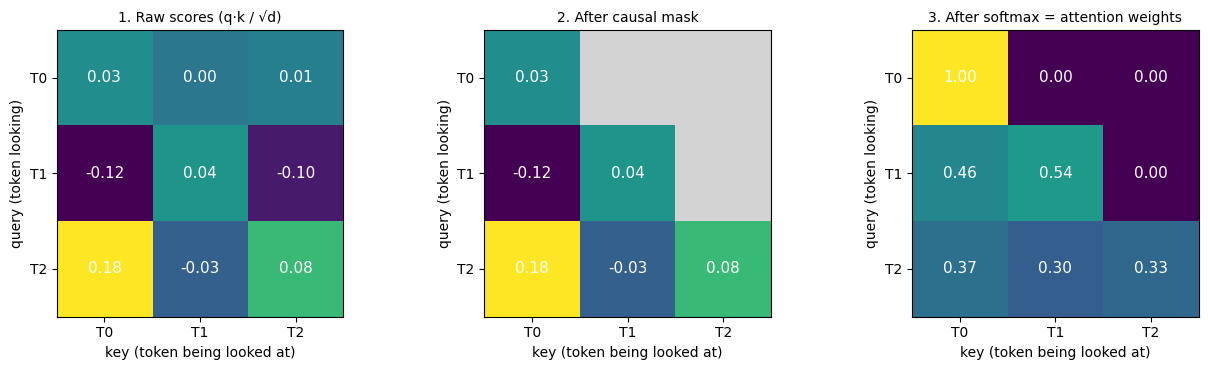

In [58]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["T0", "T1", "T2"]
sm = scores_masked[0, 0].detach()
panels = [
    ("1. Raw scores (q·k / √d)", scores[0, 0].detach()),
    ("2. After causal mask", sm.masked_fill(torch.isinf(sm), float("nan"))),
    ("3. After softmax = attention weights", weights[0, 0].detach()),
]

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("lightgray")          # masked (future) cells show as gray

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (title, M) in zip(axes, panels):
    M = M.numpy()
    ax.imshow(M, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(3)); ax.set_xticklabels(labels)
    ax.set_yticks(range(3)); ax.set_yticklabels(labels)
    ax.set_xlabel("key (token being looked at)")
    ax.set_ylabel("query (token looking)")
    for i in range(3):
        for j in range(3):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                        color="white", fontsize=11)
plt.tight_layout()
plt.savefig("attention_toy.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Transformer             

In [20]:
class RMSNorm(nn.Module):
  def __init__(self,d_model,eps=1e-6):
    super().__init__()
    self.weight=nn.Parameter(torch.ones(d_model))
    self.eps=eps

  def forward(self,x):
    rms= torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
    return x * self.weight * rms

In [21]:
class SwiGLU(nn.Module):
  def __init__(self, d_model, hidden_dim=None):
    super().__init__()
    if hidden_dim is None:
      hidden_dim = int(8 * d_model / 3)
      hidden_dim = 64 * ((hidden_dim + 63) // 64)   # round up to a multiple of 64
    self.w1 = nn.Linear(d_model, hidden_dim, bias=False)
    self.w2 = nn.Linear(d_model, hidden_dim, bias=False)
    self.w3 = nn.Linear(hidden_dim, d_model, bias=False)

  def forward(self, x):
    return self.w3(F.silu(self.w1(x)) * self.w2(x))

In [22]:
def make_norm(norm_type, d_model):
    if norm_type == "rmsnorm":
        return RMSNorm(d_model)
    elif norm_type == "layernorm":
        return nn.LayerNorm(d_model)
    raise ValueError(f"Unknown norm_type: {norm_type}")


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1,
                 use_rope=True, norm_type="rmsnorm", max_seq_len=2048):
        super().__init__()
        self.norm1 = make_norm(norm_type, d_model)
        self.attention = MultiHeadAttention(
            d_model, num_heads, dropout, use_rope, max_seq_len
        )
        self.norm2 = make_norm(norm_type, d_model)
        self.ffn = SwiGLU(d_model)

    def forward(self, x, mask=None):
        x = x + self.attention(self.norm1(x), mask)
        x = x + self.ffn(self.norm2(x))
        return x

In [23]:
d_model = 768
num_heads = 12
seq_len = 64
batch_size = 4

block = TransformerBlock(d_model, num_heads)

x = torch.randn(batch_size, seq_len, d_model)
mask = create_causal_mask(seq_len, x.device)

output = block(x, mask)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Shapes match: {x.shape == output.shape}")
print()

diff = (output - x).abs().mean().item()
print(f"Mean change after block: {diff:.4f}")
print(f"The block changed the input (it did something)")
print()

params = sum(p.numel() for p in block.parameters())
print(f"Parameters per block: {params:,}")
print(f"12 blocks: {params * 12:,} params (excluding embeddings)")

Input shape:  torch.Size([4, 64, 768])
Output shape: torch.Size([4, 64, 768])
Shapes match: True

Mean change after block: 0.1117
The block changed the input (it did something)

Parameters per block: 7,079,424
12 blocks: 84,953,088 params (excluding embeddings)


In [24]:
block.eval()
with torch.no_grad():
    for p in block.attention.parameters():
        p.zero_()
    for p in block.ffn.parameters():
        p.zero_()

x = torch.randn(1, 4, d_model)
mask = create_causal_mask(4, x.device)
output = block(x, mask)

diff = (output - x).abs().max().item()
print(f"Max difference when weights are zero: {diff:.10f}")
print(f"Input passes through unchanged (the residual works)")

Max difference when weights are zero: 0.0000000000
Input passes through unchanged (the residual works)


## 6. GPT Model

In [25]:
@dataclass
class GPTConfig:
    vocab_size: int = 50257
    max_seq_len: int = 256
    d_model: int = 384
    num_heads: int = 6
    num_layers: int = 6
    dropout: float = 0.1
    pos_type: str = "rope"        # "rope" or "learned"
    norm_type: str = "rmsnorm"    # "rmsnorm" or "layernorm"

In [26]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        c = config
        assert c.pos_type in ("rope", "learned")
        assert c.norm_type in ("rmsnorm", "layernorm")

        self.tok_emb = Embedding(c.vocab_size, c.d_model)


        self.pos_emb = (
            nn.Embedding(c.max_seq_len, c.d_model)
            if c.pos_type == "learned" else None
        )
        self.drop = nn.Dropout(c.dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(
                c.d_model, c.num_heads, c.dropout,
                use_rope=(c.pos_type == "rope"),
                norm_type=c.norm_type,
                max_seq_len=c.max_seq_len,
            )
            for _ in range(c.num_layers)
        ])

        self.final_norm = make_norm(c.norm_type, c.d_model)
        self.lm_head = nn.Linear(c.d_model, c.vocab_size, bias=False)


        self.lm_head.weight = self.tok_emb.embed.weight


        self.register_buffer(
            "causal_mask",
            create_causal_mask(c.max_seq_len, device="cpu"),
            persistent=False,
        )

        self.apply(self._init_weights)

        for name, p in self.named_parameters():
            if name.endswith("out_proj.weight") or name.endswith("w3.weight"):
                nn.init.normal_(p, mean=0.0,
                                std=0.02 / math.sqrt(2 * c.num_layers))

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.max_seq_len, "sequence longer than max_seq_len"

        x = self.tok_emb(idx)
        if self.pos_emb is not None:
            x = x + self.pos_emb(torch.arange(T, device=idx.device))
        x = self.drop(x)

        mask = self.causal_mask[:, :, :T, :T]
        for block in self.blocks:
            x = block(x, mask)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1)
            )
        return logits, loss

    def num_params(self):

        return sum(p.numel() for p in self.parameters())

In [27]:
torch.manual_seed(0)
print(f"Random-guess loss = ln(vocab) = {math.log(50257):.3f}\n")

for pos in ["rope", "learned"]:
    for norm in ["rmsnorm", "layernorm"]:
        cfg = GPTConfig(pos_type=pos, norm_type=norm)
        model = GPT(cfg).eval()

        idx = torch.randint(0, cfg.vocab_size, (2, 32))
        targets = torch.randint(0, cfg.vocab_size, (2, 32))

        with torch.no_grad():
            logits, loss = model(idx, targets)


            idx2 = idx.clone()
            idx2[:, -1] = (idx2[:, -1] + 1) % cfg.vocab_size
            logits2, _ = model(idx2)
            causal_ok = torch.allclose(logits[:, :-1], logits2[:, :-1], atol=1e-5)

        print(f"{pos:8s} + {norm:9s} | params: {model.num_params():,} | "
              f"logits: {tuple(logits.shape)} | init loss: {loss.item():.3f} | "
              f"causal: {causal_ok}")

Random-guess loss = ln(vocab) = 10.825

rope     + rmsnorm   | params: 29,920,512 | logits: (2, 32, 50257) | init loss: 10.877 | causal: True
rope     + layernorm | params: 29,925,504 | logits: (2, 32, 50257) | init loss: 10.896 | causal: True
learned  + rmsnorm   | params: 30,018,816 | logits: (2, 32, 50257) | init loss: 10.866 | causal: True
learned  + layernorm | params: 30,023,808 | logits: (2, 32, 50257) | init loss: 10.946 | causal: True


## 7. Data

In [28]:
import os, urllib.request
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cpu":
    print("Warning: no GPU. In Colab use Runtime -> Change runtime type -> T4 GPU")

Using device: cuda


In [29]:
DATA_SOURCE = "tinystories"   # "tinystories", "shakespeare", or "custom"

URLS = {
    "tinystories": "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt",
    "shakespeare": "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
}

if DATA_SOURCE == "custom":
    # Upload your own .txt file in the Colab file panel and set the name here
    data_path = "my_text.txt"
else:
    data_path = f"{DATA_SOURCE}.txt"
    if not os.path.exists(data_path):
        print("Downloading...")
        urllib.request.urlretrieve(URLS[DATA_SOURCE], data_path)

with open(data_path, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Characters: {len(text):,}")
print(f"Preview:\n{text[:400]}")

Downloading...
Characters: 22,493,387
Preview:
u don't have to be scared of the loud dog, I'll protect you". The mole felt so safe with the little girl. She was very kind and the mole soon came to trust her. He leaned against her and she kept him safe. The mole had found his best friend.
<|endoftext|>
Once upon a time, in a warm and sunny place, there was a big pit. A little boy named Tom liked to play near the pit. One day, Tom lost his red b


In [30]:
tokenizer = SimpleTokenizer()

ids = tokenizer.encode(text)
data = torch.tensor(ids, dtype=torch.long)
print(f"Total tokens: {len(data):,}")
print(f"Chars per token: {len(text) / len(data):.2f}")


split = int(0.9 * len(data))
train_data = data[:split]
val_data = data[split:]
print(f"Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")

Total tokens: 5,532,654
Chars per token: 4.07
Train tokens: 4,979,388 | Val tokens: 553,266


In [31]:
def get_batch(split, batch_size, block_size, generator=None):
    src = train_data if split == "train" else val_data
    starts = torch.randint(0, len(src) - block_size - 1, (batch_size,),
                           generator=generator)
    x = torch.stack([src[s : s + block_size] for s in starts])
    y = torch.stack([src[s + 1 : s + block_size + 1] for s in starts])
    return x.to(device), y.to(device)

In [32]:
x, y = get_batch("train", batch_size=2, block_size=12)
print(f"x shape: {x.shape} | y shape: {y.shape}\n")

for b in range(2):
    print(f"Sample {b}")
    print("  input :", repr(tokenizer.decode(x[b].tolist())))
    print("  target:", repr(tokenizer.decode(y[b].tolist())))

print("\nCheck: target is the input shifted left by one token ->",
      torch.equal(x[0, 1:], y[0, :-1]))

x shape: torch.Size([2, 12]) | y shape: torch.Size([2, 12])

Sample 0
  input : ' a time, there was a green bird. The green bird'
  target: ' time, there was a green bird. The green bird wanted'
Sample 1
  input : ' always took good care of her.\nOne sunny day,'
  target: ' took good care of her.\nOne sunny day, B'

Check: target is the input shifted left by one token -> True


## 8. Training

In [33]:
import time

@dataclass
class TrainConfig:
    batch_size: int = 32
    block_size: int = 256
    max_steps: int = 2000
    warmup_steps: int = 100
    lr: float = 6e-4
    min_lr: float = 6e-5
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    eval_interval: int = 250
    eval_iters: int = 20
    log_interval: int = 50
    seed: int = 1337

In [35]:

use_cuda = (device == "cuda")
if use_cuda and torch.cuda.get_device_capability()[0] >= 8:
    amp_dtype = torch.bfloat16
else:
    amp_dtype = torch.float16
use_scaler = use_cuda and amp_dtype == torch.float16
print(f"Mixed precision: {amp_dtype if use_cuda else 'off (CPU)'}")


def get_lr(step, tc):
    """Linear warmup, then cosine decay down to min_lr."""
    if step < tc.warmup_steps:
        return tc.lr * (step + 1) / tc.warmup_steps
    progress = (step - tc.warmup_steps) / max(1, tc.max_steps - tc.warmup_steps)
    coeff = 0.5 * (1 + math.cos(math.pi * progress))
    return tc.min_lr + coeff * (tc.lr - tc.min_lr)


def configure_optimizer(model, tc):
    """Weight decay on weight matrices only, not on norm gains or biases."""
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (decay if p.dim() >= 2 else no_decay).append(p)
    groups = [
        {"params": decay, "weight_decay": tc.weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(groups, lr=tc.lr, betas=(0.9, 0.95))


@torch.no_grad()
def estimate_val_loss(model, tc):
    """Average loss over fixed validation batches (same batches every call)."""
    model.eval()
    gen = torch.Generator().manual_seed(999)
    losses = []
    for _ in range(tc.eval_iters):
        x, y = get_batch("val", tc.batch_size, tc.block_size, gen)
        with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_cuda):
            _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

Mixed precision: torch.float16


In [34]:
def train(model_cfg, tc, run_name):
    assert tc.block_size <= model_cfg.max_seq_len
    torch.manual_seed(tc.seed)

    model = GPT(model_cfg).to(device)
    optimizer = configure_optimizer(model, tc)
    scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
    batch_gen = torch.Generator().manual_seed(tc.seed)   # same data order every run

    history = {"train_steps": [], "train_loss": [],
               "val_steps": [], "val_loss": []}

    print(f"=== {run_name} | {model.num_params():,} params ===")
    running, t0 = 0.0, time.time()
    model.train()

    for step in range(tc.max_steps):
        # periodic validation
        if step % tc.eval_interval == 0:
            val = estimate_val_loss(model, tc)
            history["val_steps"].append(step)
            history["val_loss"].append(val)
            print(f"step {step:5d} | val loss {val:.4f} | {time.time()-t0:.0f}s")

        # set the learning rate for this step
        lr = get_lr(step, tc)
        for g in optimizer.param_groups:
            g["lr"] = lr

        # forward + backward
        x, y = get_batch("train", tc.batch_size, tc.block_size, batch_gen)
        with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_cuda):
            _, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), tc.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        if (step + 1) % tc.log_interval == 0:
            history["train_steps"].append(step + 1)
            history["train_loss"].append(running / tc.log_interval)
            running = 0.0

    # final validation
    val = estimate_val_loss(model, tc)
    history["val_steps"].append(tc.max_steps)
    history["val_loss"].append(val)
    print(f"step {tc.max_steps:5d} | val loss {val:.4f} | "
          f"perplexity {math.exp(val):.2f} | total {time.time()-t0:.0f}s")

    torch.save({"model": model.state_dict(), "config": model_cfg,
                "history": history}, f"{run_name}.pt")
    return model, history

In [36]:
import matplotlib.pyplot as plt

def plot_histories(histories, title="Training curves"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        axes[0].plot(h["train_steps"], h["train_loss"], label=name)
        axes[1].plot(h["val_steps"], h["val_loss"], marker="o", label=name)
    axes[0].set_title("Train loss")
    axes[1].set_title("Validation loss")
    for ax in axes:
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

=== baseline_rope_rmsnorm | 29,920,512 params ===
step     0 | val loss 10.8908 | 2s
step   250 | val loss 2.9118 | 69s
step   500 | val loss 2.4882 | 136s
step   750 | val loss 2.2874 | 203s
step  1000 | val loss 2.1611 | 270s
step  1250 | val loss 2.0679 | 337s
step  1500 | val loss 2.0079 | 404s
step  1750 | val loss 1.9674 | 470s
step  2000 | val loss 1.9474 | perplexity 7.01 | total 537s


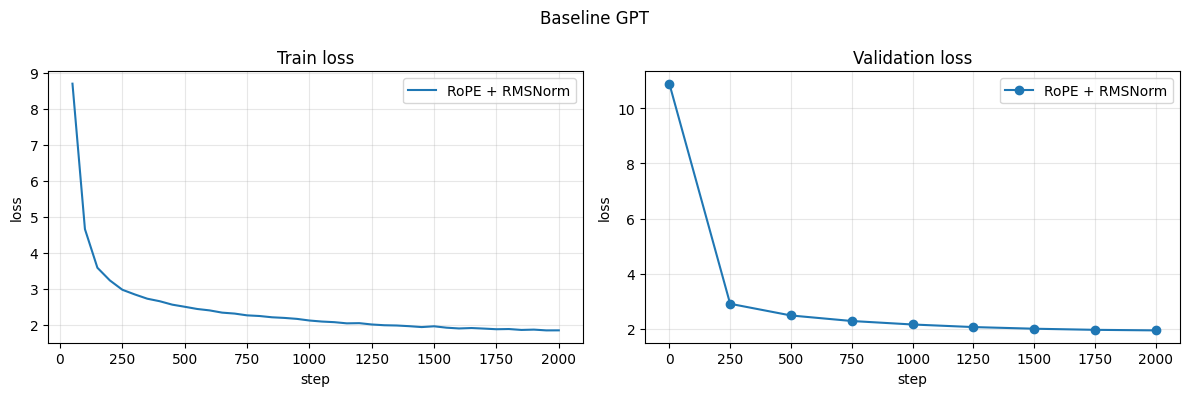

In [37]:
tc = TrainConfig()
baseline_cfg = GPTConfig(pos_type="rope", norm_type="rmsnorm")

model, baseline_hist = train(baseline_cfg, tc, "baseline_rope_rmsnorm")
plot_histories({"RoPE + RMSNorm": baseline_hist}, title="Baseline GPT")

## 9. Generation

In [ ]:
ckpt = torch.load("baseline_rope_rmsnorm.pt", map_location=device, weights_only=False)
model = GPT(ckpt["config"]).to(device)
model.load_state_dict(ckpt["model"])
model.eval()
print("Loaded checkpoint")

In [38]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=100, temperature=0.8,
             top_k=50, top_p=None, seed=None):
    model.eval()
    if seed is not None:
        torch.manual_seed(seed)

    ids = tokenizer.encode(prompt)
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    max_len = model.config.max_seq_len

    for _ in range(max_new_tokens):
        # the model can only see the last max_len tokens
        idx_cond = idx[:, -max_len:]
        with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_cuda):
            logits, _ = model(idx_cond)
        logits = logits[:, -1, :].float()          # only the last position matters

        if temperature == 0:                       # greedy
            next_id = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature

            if top_k is not None:                  # keep only the k best tokens
                kth = torch.topk(logits, top_k).values[:, -1, None]
                logits = logits.masked_fill(logits < kth, float("-inf"))

            if top_p is not None:                  # keep the smallest set with prob >= p
                sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                probs = F.softmax(sorted_logits, dim=-1)
                cum = probs.cumsum(dim=-1)
                remove = cum - probs > top_p       # always keeps at least the top token
                sorted_logits = sorted_logits.masked_fill(remove, float("-inf"))
                logits = torch.full_like(logits, float("-inf")).scatter(
                    1, sorted_idx, sorted_logits
                )

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)

        idx = torch.cat([idx, next_id], dim=1)

        if next_id.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(idx[0].tolist())

In [39]:
prompts = [
    "Once upon a time",
    "One day, a little girl named Lily",
    "The dog ran to the park and",
]

for p in prompts:
    print(f"PROMPT: {p!r}")
    print(generate(model, p, max_new_tokens=80, temperature=0.8, top_k=50, seed=42))
    print("-" * 70)

PROMPT: 'Once upon a time'
Once upon a time, there was a little boy named Tim. Tim had a friend, a big cat named Sam. They liked to play all day long. One day, they wanted to make a big mess in the kitchen. They opened the door and found a lot of mess.
Tim said, "Sam, I want to make a mess. Let's clean up it at the kitchen." They found a cup
----------------------------------------------------------------------
PROMPT: 'One day, a little girl named Lily'
One day, a little girl named Lily went to the store with her mom. Lily had a toy named Mr. Bear. Lily liked to play with Mr. Whiskers. They had lots of fun playing together in the store.
While Lily was playing, Mr. Whiskers saw a little boy named Tim. Tim asked, "Do you want to play with me?" Lily looked sad at him and said, "I want
----------------------------------------------------------------------
PROMPT: 'The dog ran to the park and'
The dog ran to the park and saw the dog. The dog was hiding behind a tree. The dog was playing an

In [40]:
prompt = "Once upon a time, there was a little"

for temp in [0.0, 0.5, 0.8, 1.2]:
    label = "greedy" if temp == 0 else f"temperature {temp}"
    print(f"=== {label} ===")
    print(generate(model, prompt, max_new_tokens=60, temperature=temp,
                   top_k=None if temp == 0 else 50, seed=7))
    print()

=== greedy ===
Once upon a time, there was a little girl named Lily. She loved to play outside in the sun. One day, she saw a big, red ball. She wanted to play with it.
Lily tried to push the ball, but it was too heavy. She tried and tried, but she could not reach it. She felt

=== temperature 0.5 ===
Once upon a time, there was a little boy named Tim. Tim loved to play outside with his friends. One day, Tim and his friends decided to go outside and play.
As they went outside, Tim saw a big, scary bear. The bear was very big and scary. Tim wanted to stop the bear, but his friends said

=== temperature 0.8 ===
Once upon a time, there was a little boy named Tim. Tim loved to play outside with his ball. One day, his ball rolled away behind a tree. Tim was very sad because he did not know where his ball went.
Tim found his ball near the tree. It was a little girl named Sue. Sue saw Tim's ball

=== temperature 1.2 ===
Once upon a time, there was a little boy named Tim. Tim liked to play gam

## 10. Evaluation

In [41]:
@torch.no_grad()
def evaluate_full(model, split="val", block_size=256, batch_size=32, max_windows=None):
    """Score non-overlapping windows. Returns loss, perplexity and per-position loss."""
    model.eval()
    src = val_data if split == "val" else train_data
    n_windows = (len(src) - 1) // block_size
    starts = torch.arange(n_windows) * block_size
    if max_windows is not None:
        starts = starts[:max_windows]

    total_loss, total_tokens = 0.0, 0
    pos_loss = torch.zeros(block_size, device=device)

    for i in range(0, len(starts), batch_size):
        s = starts[i : i + batch_size]
        x = torch.stack([src[j : j + block_size] for j in s]).to(device)
        y = torch.stack([src[j + 1 : j + block_size + 1] for j in s]).to(device)

        with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_cuda):
            logits, _ = model(x)

        tok_loss = F.cross_entropy(
            logits.float().view(-1, logits.size(-1)), y.view(-1), reduction="none"
        ).view(x.shape)

        total_loss += tok_loss.sum().item()
        total_tokens += tok_loss.numel()
        pos_loss += tok_loss.sum(dim=0)

    loss = total_loss / total_tokens
    bits_per_token = loss / math.log(2)
    chars_per_token = len(text) / len(data)      # computed in the Data section
    return {
        "loss": loss,
        "perplexity": math.exp(loss),
        "bits_per_token": bits_per_token,
        "bits_per_char": bits_per_token / chars_per_token,
        "per_position": (pos_loss / len(starts)).cpu().tolist(),
        "tokens": total_tokens,
    }

In [42]:
torch.manual_seed(0)
untrained = GPT(model.config).to(device)

res_untrained = evaluate_full(untrained, "val")
res_trained = evaluate_full(model, "val")

print(f"{'':12s} {'val loss':>9s} {'perplexity':>12s} {'bits/char':>10s}")
for name, r in [("untrained", res_untrained), ("trained", res_trained)]:
    print(f"{name:12s} {r['loss']:9.3f} {r['perplexity']:12.1f} {r['bits_per_char']:10.3f}")

print(f"\nEvaluated on {res_trained['tokens']:,} validation tokens")
print(f"Untrained perplexity is about the vocab size ({tokenizer.vocab_size:,}): "
      f"it is guessing uniformly.")
del untrained

              val loss   perplexity  bits/char
untrained       10.892      53764.2      3.865
trained          1.966          7.1      0.698

Evaluated on 553,216 validation tokens
Untrained perplexity is about the vocab size (50,257): it is guessing uniformly.


In [43]:
res_train = evaluate_full(model, "train", max_windows=len(val_data) // 256)
res_val = res_trained

print(f"Train loss: {res_train['loss']:.4f}   (perplexity {res_train['perplexity']:.2f})")
print(f"Val loss:   {res_val['loss']:.4f}   (perplexity {res_val['perplexity']:.2f})")
gap = res_val["loss"] - res_train["loss"]
print(f"Gap (val - train): {gap:+.4f}")

if gap < 0.1:
    print("Tiny gap: no real overfitting. The model could train longer or be larger.")
elif gap < 0.4:
    print("Small gap: healthy. Some memorization, mostly generalization.")
else:
    print("Large gap: overfitting. Use more data, more dropout, or fewer steps.")

Train loss: 1.7775   (perplexity 5.91)
Val loss:   1.9663   (perplexity 7.14)
Gap (val - train): +0.1888
Small gap: healthy. Some memorization, mostly generalization.


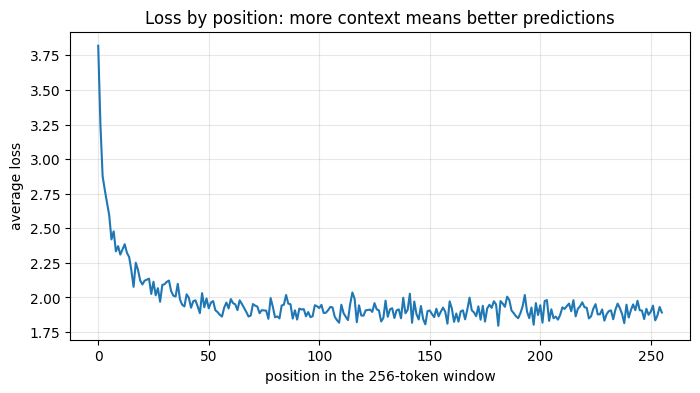

Position 0 loss:    3.820  (no context at all)
Position 10 loss:   2.310
Positions 128-255:  1.901


In [44]:
per_pos = res_trained["per_position"]

plt.figure(figsize=(8, 4))
plt.plot(per_pos)
plt.xlabel("position in the 256-token window")
plt.ylabel("average loss")
plt.title("Loss by position: more context means better predictions")
plt.grid(alpha=0.3)
plt.show()

print(f"Position 0 loss:    {per_pos[0]:.3f}  (no context at all)")
print(f"Position 10 loss:   {per_pos[10]:.3f}")
print(f"Positions 128-255:  {sum(per_pos[128:]) / len(per_pos[128:]):.3f}")

In [45]:
@torch.no_grad()
def top_next_tokens(model, prompt, k=8):
    model.eval()
    idx = torch.tensor([tokenizer.encode(prompt)], device=device)
    with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_cuda):
        logits, _ = model(idx)
    probs = F.softmax(logits[0, -1].float(), dim=-1)
    top = torch.topk(probs, k)
    print(f"PROMPT: {prompt!r}")
    for p, i in zip(top.values.tolist(), top.indices.tolist()):
        print(f"  {p*100:5.1f}%  {tokenizer.decode([i])!r}")
    print()

top_next_tokens(model, "Once upon a")
top_next_tokens(model, "The little girl was very")
top_next_tokens(model, "She picked up the ball and")
top_next_tokens(model, "The sun is")

PROMPT: 'Once upon a'
   99.9%  ' time'
    0.0%  ' walk'
    0.0%  ' while'
    0.0%  ' few'
    0.0%  ' day'
    0.0%  ' week'
    0.0%  ' journey'
    0.0%  ' moment'

PROMPT: 'The little girl was very'
   42.2%  ' happy'
   10.8%  ' sad'
   10.6%  ' excited'
    4.0%  ' curious'
    2.7%  ' surprised'
    2.6%  ' proud'
    1.9%  ' glad'
    1.8%  ' scared'

PROMPT: 'She picked up the ball and'
   16.8%  ' threw'
   13.7%  ' ran'
   10.3%  ' put'
    9.9%  ' started'
    4.3%  ' said'
    4.0%  ' took'
    3.2%  ' tried'
    3.0%  ' went'

PROMPT: 'The sun is'
   17.6%  ' shining'
    9.6%  ' hot'
    8.3%  ' going'
    6.8%  ' very'
    5.1%  ' bright'
    3.6%  ' ready'
    3.2%  ' not'
    3.0%  ' warm'



In [46]:
results = {}
results["RoPE + RMSNorm"] = {
    "params": model.num_params(),
    "val_loss": res_trained["loss"],
    "perplexity": res_trained["perplexity"],
    "bits_per_char": res_trained["bits_per_char"],
    "train_loss": res_train["loss"],
}

import json
print(json.dumps(results, indent=2))

{
  "RoPE + RMSNorm": {
    "params": 29920512,
    "val_loss": 1.9662763215170476,
    "perplexity": 7.144024846466925,
    "bits_per_char": 0.6977466244894815,
    "train_loss": 1.7774891974693203
  }
}


## 11. Visualizing Attention

In [48]:
@torch.no_grad()
def get_attention(model, text):
    """Run one forward pass and return (tokens, attention) with attention shape (L, H, T, T)."""
    model.eval()
    ids = tokenizer.encode(text)
    idx = torch.tensor([ids], device=device)

    for blk in model.blocks:
        blk.attention.store_attn = True
    model(idx)
    attn = torch.stack([blk.attention.last_attn[0] for blk in model.blocks]).float()
    for blk in model.blocks:
        blk.attention.store_attn = False
        blk.attention.last_attn = None

    toks = [tokenizer.decode([i]).replace("\n", "\\n").strip() or "·" for i in ids]
    return toks, attn


def plot_attention(attn, toks, layer, head, ax=None, title=None):
    A = attn[layer, head].numpy()
    T = len(toks)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(A, cmap="viridis", vmin=0, vmax=max(A.max(), 1e-6))
    ax.set_xticks(range(T)); ax.set_xticklabels(toks, rotation=90, fontsize=8)
    ax.set_yticks(range(T)); ax.set_yticklabels(toks, fontsize=8)
    ax.set_xlabel("key (looked at)")
    ax.set_ylabel("query (looking)")
    ax.set_title(title or f"Layer {layer}, Head {head}", fontsize=10)
    if standalone:
        plt.colorbar(im, ax=ax, fraction=0.046)
        plt.tight_layout()
        plt.show()

In [49]:
sentence = "One day, a little girl named Lily found a red ball in the park."
toks, attn = get_attention(model, sentence)
print(f"{len(toks)} tokens: {toks}")
print(f"Attention tensor shape (layers, heads, T, T): {tuple(attn.shape)}")

16 tokens: ['One', 'day', ',', 'a', 'little', 'girl', 'named', 'Lily', 'found', 'a', 'red', 'ball', 'in', 'the', 'park', '.']
Attention tensor shape (layers, heads, T, T): (6, 6, 16, 16)


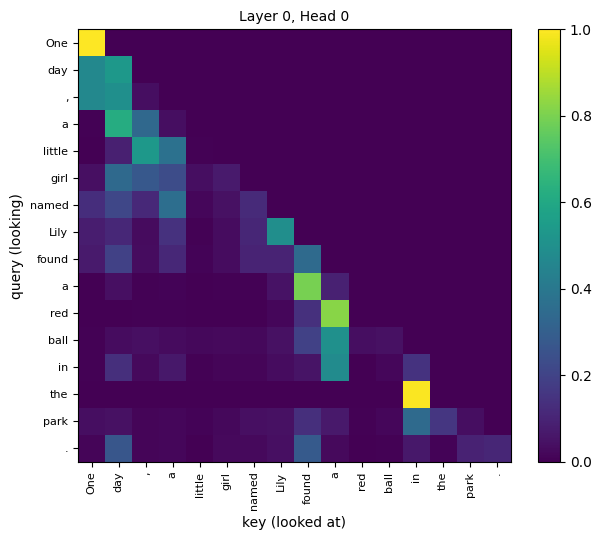

In [50]:
plot_attention(attn, toks, layer=0, head=0)

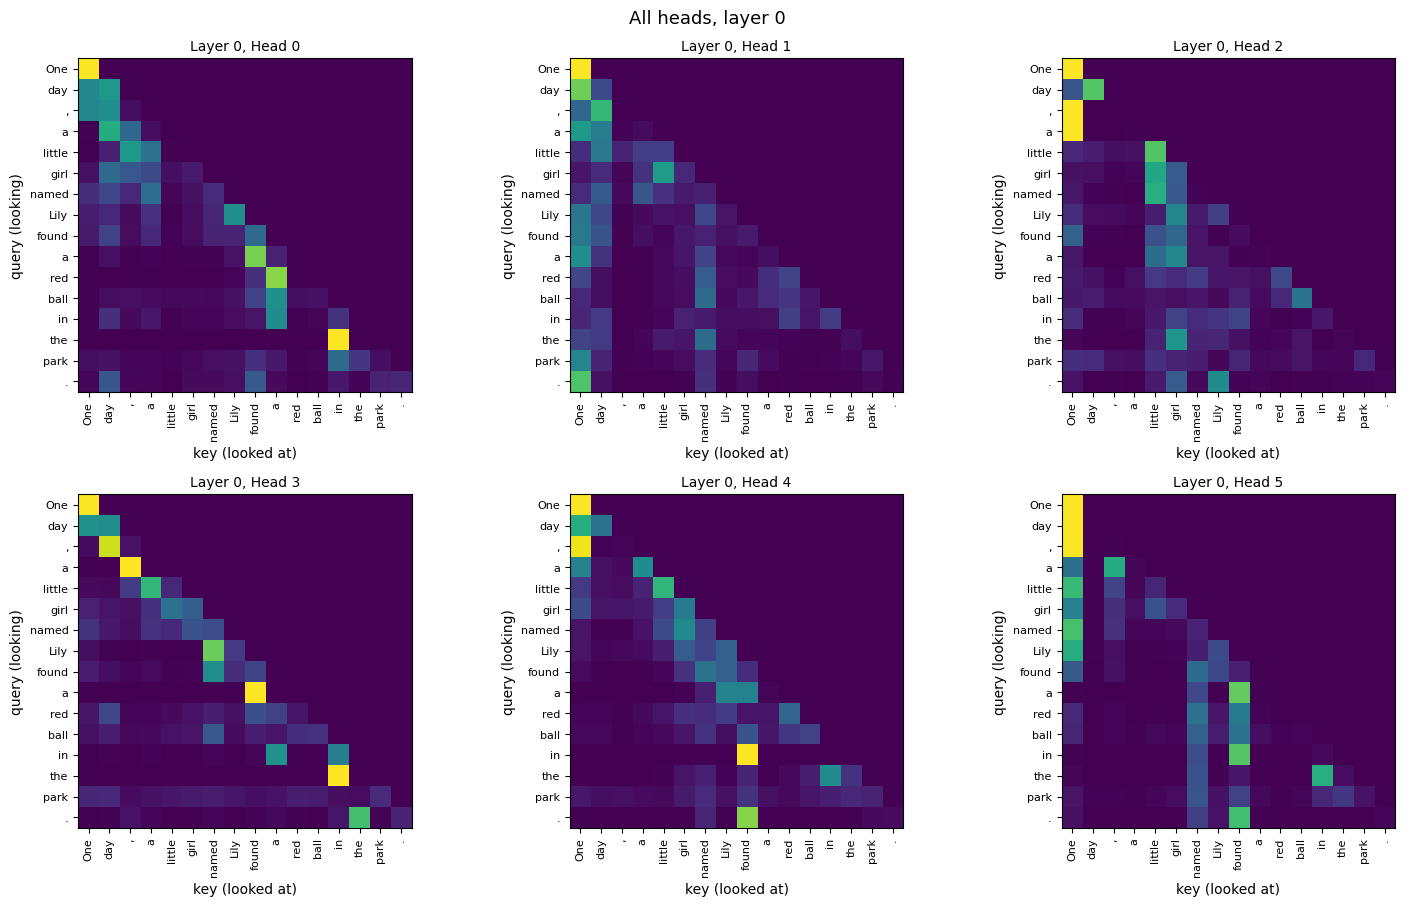

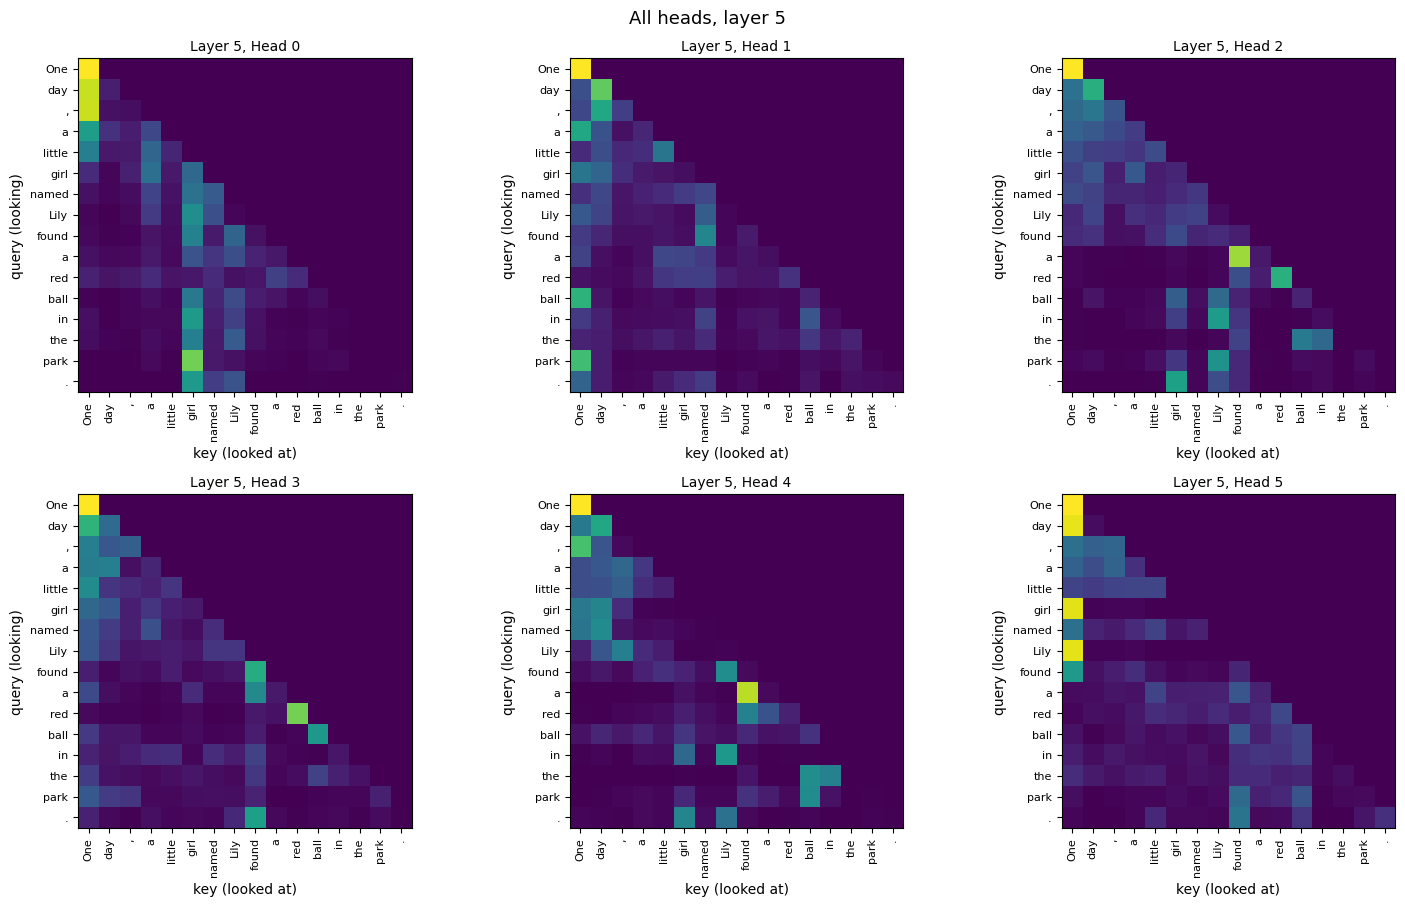

In [51]:
def plot_layer(attn, toks, layer, save_as=None):
    H = attn.shape[1]
    cols = 3
    rows = math.ceil(H / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.6 * rows))
    axes = np.array(axes).reshape(-1)
    for h in range(H):
        plot_attention(attn, toks, layer, h, ax=axes[h])
    for ax in axes[H:]:
        ax.axis("off")
    fig.suptitle(f"All heads, layer {layer}", fontsize=13)
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=130, bbox_inches="tight")
    plt.show()

plot_layer(attn, toks, layer=0, save_as="attention_layer0.png")
plot_layer(attn, toks, layer=attn.shape[0] - 1, save_as="attention_last_layer.png")

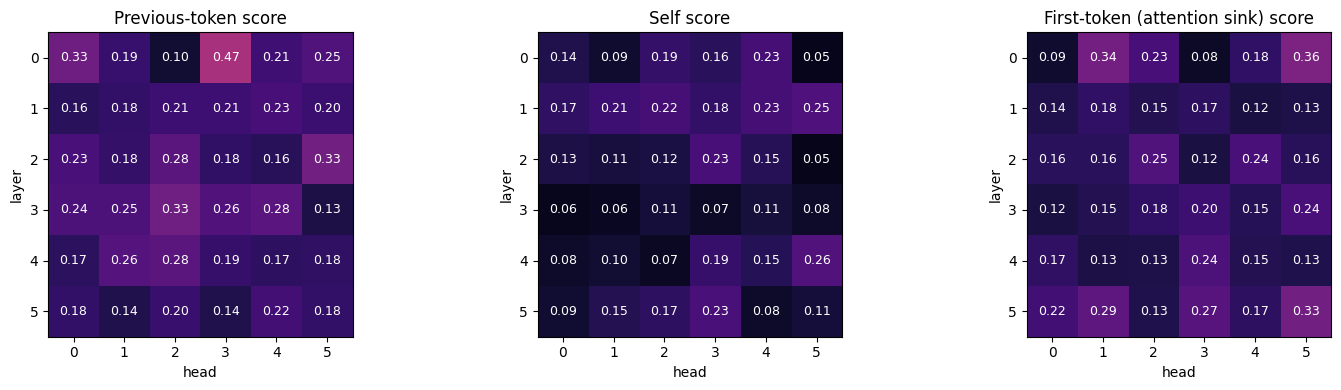

In [52]:
L, H, T, _ = attn.shape
pos = torch.arange(1, T)

prev_tok = torch.zeros(L, H); self_att = torch.zeros(L, H); first_tok = torch.zeros(L, H)
for l in range(L):
    for h in range(H):
        A = attn[l, h]
        prev_tok[l, h]  = A[pos, pos - 1].mean()
        self_att[l, h]  = A[pos, pos].mean()
        first_tok[l, h] = A[pos, 0].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, M) in zip(axes, [("Previous-token", prev_tok),
                                ("Self", self_att),
                                ("First-token (attention sink)", first_tok)]):
    ax.imshow(M.numpy(), cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"{name} score")
    ax.set_xlabel("head"); ax.set_ylabel("layer")
    ax.set_xticks(range(H)); ax.set_yticks(range(L))
    for l in range(L):
        for h in range(H):
            v = M[l, h].item()
            ax.text(h, l, f"{v:.2f}", ha="center", va="center",
                    color="white" if v < 0.6 else "black", fontsize=9)
plt.tight_layout()
plt.savefig("attention_head_roles.png", dpi=150, bbox_inches="tight")
plt.show()

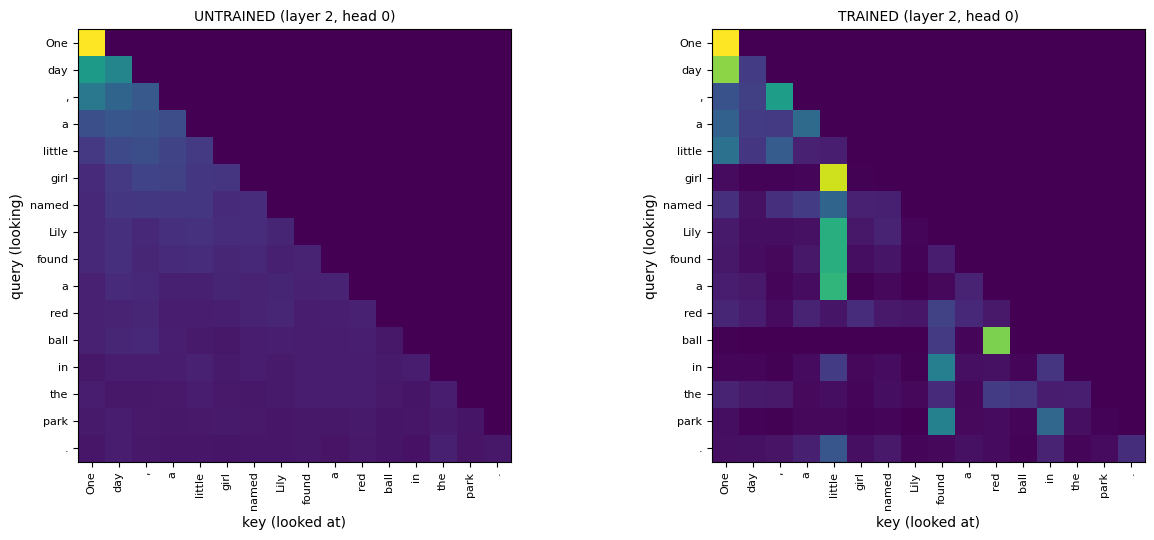

In [54]:
torch.manual_seed(0)
untrained = GPT(model.config).to(device)
toks_u, attn_u = get_attention(untrained, sentence)

layer, head = 2, 0
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_attention(attn_u, toks_u, layer, head, ax=axes[0],
               title=f"UNTRAINED (layer {layer}, head {head})")
plot_attention(attn, toks, layer, head, ax=axes[1],
               title=f"TRAINED (layer {layer}, head {head})")
plt.tight_layout()
plt.savefig("attention_untrained_vs_trained.png", dpi=150, bbox_inches="tight")
plt.show()
del untrained

## 12. Ablation Experiments

In [55]:
EXPERIMENTS = {
    # display name:        (checkpoint name,         config overrides)
    "RoPE + RMSNorm":      ("baseline_rope_rmsnorm", dict(pos_type="rope",    norm_type="rmsnorm")),
    "RoPE + LayerNorm":    ("abl_rope_layernorm",    dict(pos_type="rope",    norm_type="layernorm")),
    "Learned + RMSNorm":   ("abl_learned_rmsnorm",   dict(pos_type="learned", norm_type="rmsnorm")),
    "Learned + LayerNorm": ("abl_learned_layernorm", dict(pos_type="learned", norm_type="layernorm")),
}

tc = TrainConfig()     # one shared config for every run
runs = {}              # display name -> (model, history)


def run_or_load(name):
    ckpt_name, spec = EXPERIMENTS[name]
    path = f"{ckpt_name}.pt"
    if os.path.exists(path):
        ckpt = torch.load(path, map_location=device, weights_only=False)
        m = GPT(ckpt["config"]).to(device)
        m.load_state_dict(ckpt["model"])
        m.eval()
        print(f"[loaded] {name} from {path}")
        return m, ckpt["history"]
    return train(GPTConfig(**spec), tc, ckpt_name)

In [57]:
for name in EXPERIMENTS:
    runs[name] = run_or_load(name)
    ckpt_file = EXPERIMENTS[name][0] + ".pt"
    if "backup" in globals():            # only if you ran the Drive cell
        backup(ckpt_file)
    torch.cuda.empty_cache()

print("\nAll runs ready:", list(runs))

[loaded] RoPE + RMSNorm from baseline_rope_rmsnorm.pt
=== abl_rope_layernorm | 29,925,504 params ===
step     0 | val loss 10.8915 | 2s
step   250 | val loss 2.9019 | 64s
step   500 | val loss 2.4849 | 127s
step   750 | val loss 2.2853 | 190s
step  1000 | val loss 2.1579 | 253s
step  1250 | val loss 2.0636 | 315s
step  1500 | val loss 2.0048 | 378s
step  1750 | val loss 1.9639 | 441s
step  2000 | val loss 1.9435 | perplexity 6.98 | total 504s
=== abl_learned_rmsnorm | 30,018,816 params ===
step     0 | val loss 10.9061 | 2s
step   250 | val loss 3.2932 | 65s
step   500 | val loss 2.7099 | 129s
step   750 | val loss 2.4446 | 192s
step  1000 | val loss 2.2851 | 256s
step  1250 | val loss 2.1696 | 319s
step  1500 | val loss 2.0951 | 382s
step  1750 | val loss 2.0491 | 445s
step  2000 | val loss 2.0232 | perplexity 7.56 | total 509s
=== abl_learned_layernorm | 30,023,808 params ===
step     0 | val loss 10.9042 | 2s
step   250 | val loss 3.2885 | 62s
step   500 | val loss 2.7009 | 122s
ste

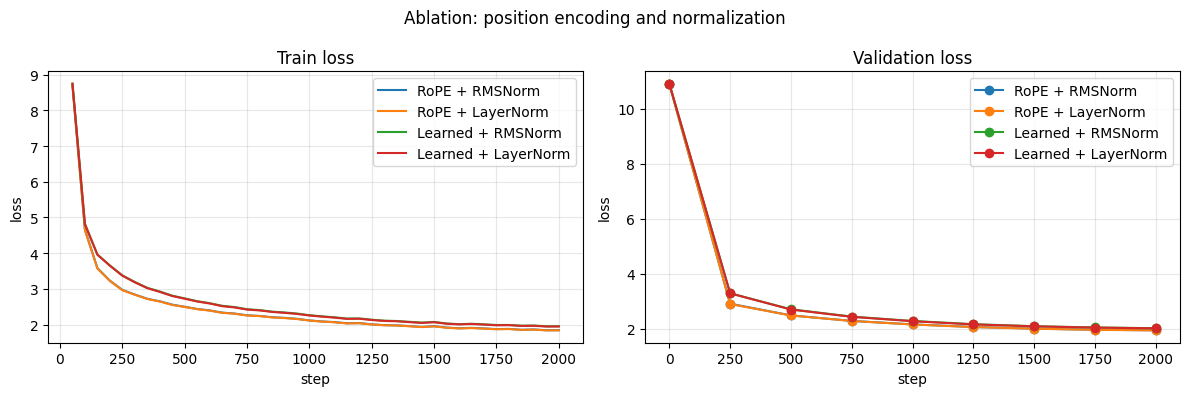

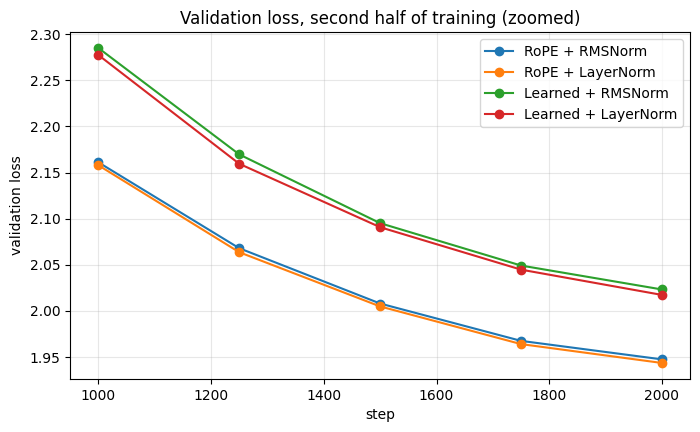

In [59]:
histories = {name: h for name, (_, h) in runs.items()}
plot_histories(histories, title="Ablation: position encoding and normalization")

plt.figure(figsize=(8, 4.5))
for name, h in histories.items():
    pts = [(s, v) for s, v in zip(h["val_steps"], h["val_loss"]) if s >= tc.max_steps // 2]
    plt.plot(*zip(*pts), marker="o", label=name)
plt.xlabel("step"); plt.ylabel("validation loss")
plt.title("Validation loss, second half of training (zoomed)")
plt.grid(alpha=0.3); plt.legend()
plt.savefig("ablation_curves_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
results = {}
for name, (m, h) in runs.items():
    r = evaluate_full(m, "val")
    results[name] = {
        "params": m.num_params(),
        "val_loss": r["loss"],
        "perplexity": r["perplexity"],
        "bits_per_char": r["bits_per_char"],
        "final_train_loss": h["train_loss"][-1],
    }

base = results["RoPE + RMSNorm"]["val_loss"]
print(f"{'model':22s} {'params':>12s} {'val loss':>9s} {'ppl':>8s} {'vs base':>9s}")
for name, r in sorted(results.items(), key=lambda kv: kv[1]["val_loss"]):
    print(f"{name:22s} {r['params']:12,d} {r['val_loss']:9.4f} "
          f"{r['perplexity']:8.2f} {r['val_loss'] - base:+9.4f}")

with open("ablation_results.json", "w") as f:
    json.dump(results, f, indent=2)

model                        params  val loss      ppl   vs base
RoPE + LayerNorm         29,925,504    1.9622     7.11   -0.0041
RoPE + RMSNorm           29,920,512    1.9663     7.14   +0.0000
Learned + LayerNorm      30,023,808    2.0385     7.68   +0.0722
Learned + RMSNorm        30,018,816    2.0447     7.73   +0.0785


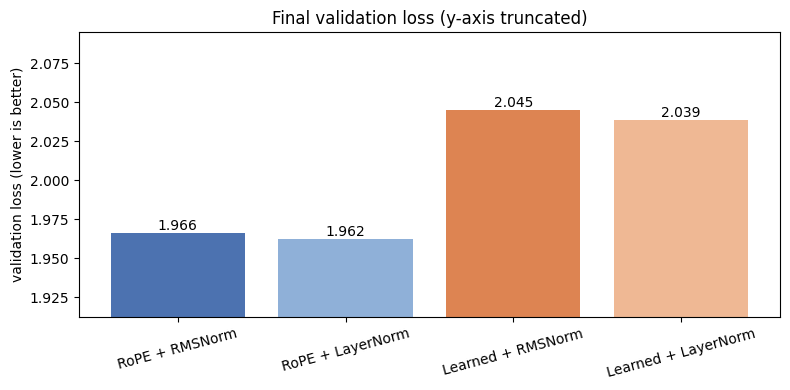

In [61]:
names = list(results)
vals = [results[n]["val_loss"] for n in names]

plt.figure(figsize=(8, 4))
bars = plt.bar(names, vals, color=["#4c72b0", "#8fb0d8", "#dd8452", "#efb894"])
plt.ylim(min(vals) - 0.05, max(vals) + 0.05)     # truncated axis on purpose
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom")
plt.ylabel("validation loss (lower is better)")
plt.title("Final validation loss (y-axis truncated)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("ablation_bars.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
noise_losses = [results["RoPE + RMSNorm"]["val_loss"]]
for seed in [1, 2]:
    tc_s = TrainConfig(seed=seed)
    cfg = GPTConfig(pos_type="rope", norm_type="rmsnorm")
    path = f"noise_seed{seed}.pt"
    if os.path.exists(path):
        ck = torch.load(path, map_location=device, weights_only=False)
        m = GPT(ck["config"]).to(device); m.load_state_dict(ck["model"])
    else:
        m, _ = train(cfg, tc_s, f"noise_seed{seed}")
    noise_losses.append(evaluate_full(m, "val")["loss"])
    del m; torch.cuda.empty_cache()

lo, hi = min(noise_losses), max(noise_losses)
print(f"Baseline val loss across 3 seeds: {[round(x, 4) for x in noise_losses]}")
print(f"Spread (max - min): {hi - lo:.4f}")
print("Differences smaller than this spread are NOT trustworthy.")

=== noise_seed1 | 29,920,512 params ===
step     0 | val loss 10.9147 | 2s
step   250 | val loss 2.9037 | 69s
step   500 | val loss 2.4857 | 136s
step   750 | val loss 2.3020 | 203s
step  1000 | val loss 2.1600 | 270s
step  1250 | val loss 2.0721 | 336s
step  1500 | val loss 2.0090 | 403s
step  1750 | val loss 1.9707 | 470s
step  2000 | val loss 1.9471 | perplexity 7.01 | total 536s
=== noise_seed2 | 29,920,512 params ===
step     0 | val loss 10.8897 | 2s
step   250 | val loss 2.8845 | 69s
step   500 | val loss 2.4817 | 136s
step   750 | val loss 2.2865 | 203s
step  1000 | val loss 2.1588 | 269s
step  1250 | val loss 2.0691 | 336s
step  1500 | val loss 2.0065 | 403s
step  1750 | val loss 1.9678 | 469s
step  2000 | val loss 1.9470 | perplexity 7.01 | total 536s
Baseline val loss across 3 seeds: [1.9663, 1.9658, 1.9643]
Spread (max - min): 0.0020
Differences smaller than this spread are NOT trustworthy.


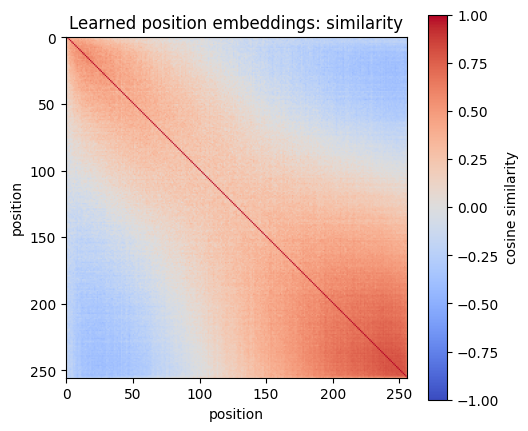

Avg similarity, neighboring positions: 0.443
Avg similarity, 128 apart:             -0.052

Strongest previous-token head per layer:
  RoPE + RMSNorm       [0.47, 0.23, 0.33, 0.33, 0.28, 0.22]
  Learned + RMSNorm    [0.19, 0.18, 0.2, 0.35, 0.37, 0.25]


In [63]:
lm = runs["Learned + RMSNorm"][0]
W = F.normalize(lm.pos_emb.weight.detach().float().cpu(), dim=-1)
sim = (W @ W.T).numpy()

plt.figure(figsize=(5.5, 5))
plt.imshow(sim, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="cosine similarity")
plt.xlabel("position"); plt.ylabel("position")
plt.title("Learned position embeddings: similarity")
plt.savefig("learned_pos_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

near = np.mean([sim[i, i + 1] for i in range(255)])
far = np.mean([sim[i, i + 128] for i in range(128)])
print(f"Avg similarity, neighboring positions: {near:.3f}")
print(f"Avg similarity, 128 apart:             {far:.3f}")

def prev_token_scores(attn):
    L, H, T, _ = attn.shape
    pos = torch.arange(1, T)
    return torch.stack([torch.stack([attn[l, h][pos, pos - 1].mean() for h in range(H)])
                        for l in range(L)])

sentence = "One day, a little girl named Lily found a red ball in the park."
print("\nStrongest previous-token head per layer:")
for name in ["RoPE + RMSNorm", "Learned + RMSNorm"]:
    _, a = get_attention(runs[name][0], sentence)
    best = prev_token_scores(a).max(dim=1).values
    print(f"  {name:20s}", [round(v, 2) for v in best.tolist()])